## Thailand

In [2]:
import pandas as pd
import geopandas as gpd

df_thailand = gpd.read_file("../ADB_ RoadPulse/AI for Safer Roads 2026 - Dataset/ADB_Innovation_Thailand.geojson")
print(df_thailand.shape)
df_thailand.head()

(55884, 27)


,OBJECTID,english_ro,OvertureID,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,RoadClass,...,InvPercentile,AnalysisStatus,RankedPercentile,StreetImageLink,LandUse,NO_OF_Result_Segments,PercentileBand,SampleSizeTotal,Shape_Length,geometry
0,1,Surin Ring Road,1,NaN,4.632086,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.4699393,14.839138,103.43891053,14.86699584",NaN,NaN,NaN,NaN,4632.086492,"LINESTRING (103.46994 14.83914, 103.46967 14.8..."
1,2,Surin Ring Road,2,44479.6,2.300000,102303.08,0.000002,0.002591,66.0,primary,...,0.997409,Valid,26.253458,"103.43891053,14.86699584,103.48332214,14.94166589",RURAL,1.0,0-5%,222398.0,11672.918346,"LINESTRING (103.43891 14.867, 103.4383 14.8677..."
2,3,Surin Ring Road,3,NaN,0.122010,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.48332214,14.94166589,103.48440114,14.94199564",NaN,NaN,NaN,NaN,122.010111,"LINESTRING (103.48332 14.94167, 103.48405 14.9..."
3,4,Surin Ring Road,4,NaN,2.045467,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.48440114,14.94199564,103.50325276,14.94199566",NaN,NaN,NaN,NaN,2045.467119,"LINESTRING (103.4844 14.942, 103.4846 14.94205..."
4,5,Surin Ring Road,5,NaN,2.028143,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.50325276,14.94199566,103.5216215,14.9380875",NaN,NaN,NaN,NaN,2028.142985,"LINESTRING (103.50325 14.942, 103.5072 14.9411..."


In [3]:
# drop null values from df_thailand
df_thailand = df_thailand.dropna()
df_thailand.shape

(11544, 27)

In [ ]:
# accident data
df_acc_thailand = pd.read_csv('thailand_road_accident_fatalities_2024.csv')
print(df_acc_thailand.shape)
df_acc_thailand.head()

(12762, 13)


,age,sex,nationality,person_district,person_province,confirmed_death_date,acc_sub_district,acc_district,province_of_death,acc_lat,acc_long,cause_code,vehicle_type
0,49.0,ชาย,NaN,ขนอม,นครศรีธรรมราช,11/01/2567,ขนอม,ขนอม,นครศรีธรรมราช,99.857347,9.182572,V899,รถจักรยานยนต์
1,59.0,หญิง,NaN,พล,ขอนแก่น,13/03/2567,เมืองพล,พล,ขอนแก่น,NaN,NaN,V031,คนเดินเท้า
2,15.0,ชาย,NaN,บัวเชด,สุรินทร์,30/06/2567,ละลม,ภูสิงห์,ศรีสะเกษ,104.013630,14.567701,V892,รถจักรยานยนต์
3,19.0,ชาย,NaN,แม่สอด,ตาก,02/07/2567,หางน้ำสาคร,เมืองชัยนาท,ชัยนาท,100.180372,15.295001,V244,รถจักรยานยนต์
4,44.0,ชาย,NaN,ชานุมาน,อำนาจเจริญ,06/07/2567,ป่าก่อ,ชานุมาน,อำนาจเจริญ,NaN,NaN,Y349,ไม่ระบุพาหนะ


In [ ]:
# drop null values from df_acc_thailand for long and lat
df_acc_thailand = df_acc_thailand.dropna(subset=['acc_long', 'acc_lat'])
df_acc_thailand.shape

(3246, 13)

In [13]:
print(df_acc_thailand[["acc_lat", "acc_long"]].dtypes)
print(df_acc_thailand[["acc_lat", "acc_long"]].head())
print(df_acc_thailand[["acc_lat", "acc_long"]].describe())

acc_lat     float64
acc_long    float64
dtype: object
      acc_lat   acc_long
0   99.857347   9.182572
2  104.013630  14.567701
3  100.180372  15.295001
5  100.335430  14.627385
6   99.492564  19.580651
           acc_lat     acc_long
count  3246.000000  3246.000000
mean    101.017409    14.664524
std       1.546144     2.925550
min      97.917557     5.942709
25%      99.957873    13.609864
50%     100.618084    14.636249
75%     101.957632    16.671036
max     105.570887    20.440413


In [ ]:
# here lat is actually longitude and long is actually latitude
# For thailand, it should be roughly
# latitude  = 5 to 21
# longitude = 97 to 106

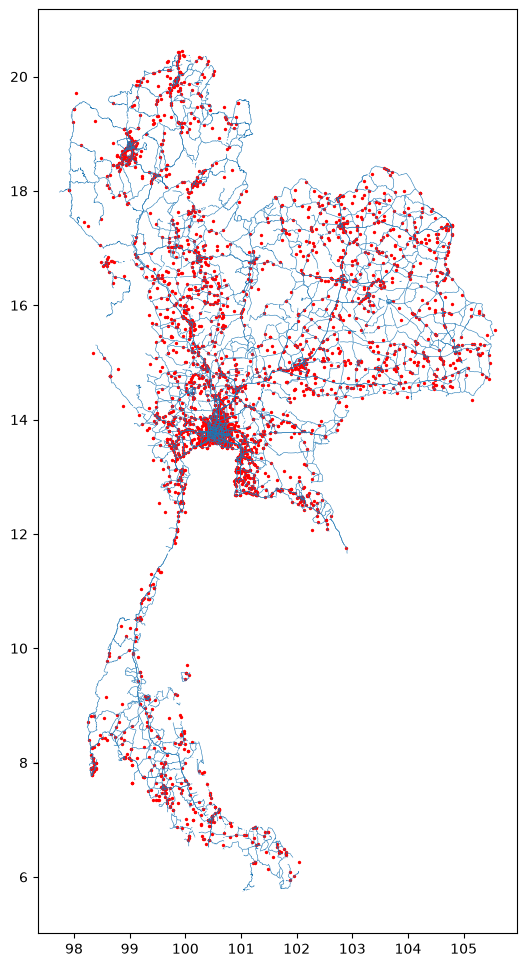

In [14]:
# let's draw the roads 
from shapely.geometry import Point
import geopandas as gpd

gdf_acc = gpd.GeoDataFrame(
    df_acc_thailand,
    geometry=gpd.points_from_xy(
        df_acc_thailand["acc_lat"],   # actually longitude
        df_acc_thailand["acc_long"]   # actually latitude
    ),
    crs="EPSG:4326"
)


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

df_thailand.plot(ax=ax, linewidth=0.4)
gdf_acc.plot(ax=ax, color="red", markersize=2)

plt.show()

## Map Accidents with Roads

In [65]:
# Convert road and accident geodataframes to metric CRS (meters)
roads_m = df_thailand.to_crs(epsg=3857)
acc_m = gdf_acc.to_crs(epsg=3857)

# Match every accident point to the nearest road segment
matched = gpd.sjoin_nearest(
    acc_m,
    roads_m[["OBJECTID", "geometry"]],
    how="left",
    distance_col="distance_to_road_m"
)

In [66]:
matched["distance_to_road_m"].describe()

count     3258.000000
mean      1545.190363
std       2708.804886
min          0.001954
25%          6.944188
50%        301.051662
75%       1955.907272
max      24552.718498
Name: distance_to_road_m, dtype: float64

In [67]:
# Keep only accidents within 50 meters of a road
# Accidents farther away are ignored to reduce wrong assignments

THRESHOLD_M = 50

matched_50m = matched[
    matched["distance_to_road_m"] <= THRESHOLD_M
].copy()

print("Total accidents:", len(acc_m))
print("Matched accidents:", len(matched_50m))

Total accidents: 3246
Matched accidents: 1326


In [68]:
# Count number of accidents assigned to each road segment

accident_counts = (
    matched_50m
    .groupby("OBJECTID")
    .size()
    .reset_index(name="accident_count")
)

print(accident_counts.shape)
accident_counts.head()

(999, 2)


,OBJECTID,accident_count
0,19,2
1,33,2
2,39,1
3,40,1
4,43,1


In [69]:
# Extract road length for each road segment
# Length is computed in meters, then converted to kilometers

road_lengths = roads_m[["OBJECTID", "geometry"]].copy()

road_lengths["road_length_m"] = road_lengths.geometry.length
road_lengths["road_length_km"] = road_lengths["road_length_m"] / 1000

road_lengths = road_lengths.drop(columns="geometry")

road_lengths.head()

,OBJECTID,road_length_m,road_length_km
1,2,12090.980013,12.090980
5,6,2184.912134,2.184912
6,7,1919.390191,1.919390
8,9,12060.829934,12.060830
17,18,733.080319,0.733080


In [70]:
# Create a clean dataframe containing:
# road id + road length + accident count

df_accident_by_road = road_lengths.merge(
    accident_counts,
    on="OBJECTID",
    how="left"
)

# Roads with no accidents get count = 0
df_accident_by_road["accident_count"] = (
    df_accident_by_road["accident_count"]
    .fillna(0)
    .astype(int)
)

print(df_accident_by_road.shape)
df_accident_by_road.head()

(11544, 4)


,OBJECTID,road_length_m,road_length_km,accident_count
0,2,12090.980013,12.090980,0
1,6,2184.912134,2.184912,0
2,7,1919.390191,1.919390,0
3,9,12060.829934,12.060830,0
4,18,733.080319,0.733080,0


In [ ]:
# Compute accident density per kilometer
# This is better than raw count because it normalizes for road length

df_accident_by_road["accidents_per_km"] = (
    df_accident_by_road["accident_count"] /
    df_accident_by_road["road_length_km"]
)

#drop the road_length_km column
df_accident_by_road = df_accident_by_road.drop(columns=["road_length_km", "road_length_m"])
df_accident_by_road.tail()

,OBJECTID,accident_count,accidents_per_km
11539,55873,1,0.025662
11540,55874,2,0.196151
11541,55875,0,0.000000
11542,55881,0,0.000000
11543,55882,0,0.000000


In [72]:
df_accident_by_road.describe()

,OBJECTID,accident_count,accidents_per_km
count,11544.000000,11544.000000,11544.000000
mean,33890.804401,0.114865,0.031044
std,14402.511803,0.434349,0.198170
min,2.000000,0.000000,0.000000
25%,21642.750000,0.000000,0.000000
50%,35775.500000,0.000000,0.000000
75%,45340.500000,0.000000,0.000000
max,55882.000000,8.000000,9.390515


In [74]:
matched["distance_to_road_m"].describe([0.5, 0.75, 0.9, 0.95, 0.99])

count     3258.000000
mean      1545.190363
std       2708.804886
min          0.001954
50%        301.051662
75%       1955.907272
90%       4723.466566
95%       7414.844181
99%      12955.476852
max      24552.718498
Name: distance_to_road_m, dtype: float64

In [139]:
# add a column named accident history (high, medium, low)
# Get nonzero accident densities
nonzero = df_accident_by_road.loc[ df_accident_by_road["accidents_per_km"] > 0, "accidents_per_km"]

# Compute 75th percentile
q75 = nonzero.quantile(0.75)

# Classification function
def accident_class(x):
    if x == 0:
        return "low"
    elif x < q75:
        return "risky"
    else:
        return "risky"

# Apply classification
df_accident_by_road["accident_history"] = (
    df_accident_by_road["accidents_per_km"].apply(accident_class)
)

print(df_accident_by_road["accident_history"].value_counts())
df_accident_by_road.head()

accident_history
low      10545
risky      999
Name: count, dtype: int64


,OBJECTID,accident_count,accidents_per_km,accident_history
0,2,0,0.0,low
1,6,0,0.0,low
2,7,0,0.0,low
3,9,0,0.0,low
4,18,0,0.0,low


## Variables From Image

In [140]:
df_variable_thailand = pd.read_csv("variables_thailand.csv")
print(df_variable_thailand.shape)
df_variable_thailand.columns


(11544, 56)


Index(['road_id', 'OBJECTID', 'DISSOLVE_ID', 'class', 'subtype', 'RoadClass',
       'LandUse', 'RoadLength', 'SpeedLimit', 'SpeedLimitFloor',
       'PercentileBand', 'RankedPercentile', 'MedianSpeed',
       'F85thPercentileSpeed', 'PercentOverLimit', 'NumberOverLimit', 'Pass',
       'ExcludeFromSpeedSPI', 'AnalysisStatus', 'coord_lng1', 'coord_lat1',
       'coord_lng2', 'coord_lat2', 'StreetImageLink', 'Shape_Length',
       'yolo_images_found', 'yolo_total_vehicles', 'yolo_total_pedestrians',
       'yolo_total_cars', 'yolo_total_trucks', 'yolo_total_buses',
       'yolo_total_motorcycles', 'yolo_total_bicycles',
       'yolo_max_vehicles_single_image', 'yolo_avg_vehicles_per_image',
       'yolo_per_heading_json', 'vlm_images_sent', 'vlm_greenery_score',
       'vlm_greenery_intensity', 'vlm_footpath_score', 'vlm_lighting_score',
       'vlm_shade_score', 'vlm_road_condition_score',
       'vlm_building_height_score', 'vlm_building_density_score',
       'vlm_population_density_

## Merge with accident data

In [141]:
# Merge image-derived variables with accident history using OBJECTID
# This creates the modeling dataset for learning image-risk weights

df_model = df_variable_thailand.merge(
    df_accident_by_road[["OBJECTID", "accident_count", "accidents_per_km", "accident_history"]],
    on="OBJECTID",
    how="left"
)

# Fill roads with no accident match as low accident history
df_model["accident_count"] = df_model["accident_count"].fillna(0).astype(int)
df_model["accidents_per_km"] = df_model["accidents_per_km"].fillna(0)
df_model["accident_history"] = df_model["accident_history"].fillna("low")

print(df_model.shape)
df_model.head()

(11544, 59)


,road_id,OBJECTID,DISSOLVE_ID,class,subtype,RoadClass,LandUse,RoadLength,SpeedLimit,SpeedLimitFloor,...,vlm_lane_count,vlm_curvature_visible,vlm_intersection_visible,vlm_lane_width_estimate,vlm_vlm_notes,yolo_processed_at,vlm_processed_at,accident_count,accidents_per_km,accident_history
0,2,2,NaN,NaN,NaN,primary,RURAL,2.3,66,60,...,2.0,0.0,0.0,standard,The road is surrounded by sparse vegetation an...,2026-06-23 06:05:51,2026-06-23 06:21:31,0,0.0,low
1,6,6,NaN,NaN,NaN,primary,URBAN,1.9,70,70,...,4.0,0.0,1.0,standard,The road is straight with moderate traffic and...,2026-06-23 06:05:53,2026-06-23 06:21:34,0,0.0,low
2,7,7,NaN,NaN,NaN,primary,RURAL,1.9,30,30,...,4.0,0.0,0.0,standard,"The road is wide and straight, with no visible...",2026-06-23 06:05:55,2026-06-23 06:21:37,0,0.0,low
3,9,9,NaN,NaN,NaN,primary,RURAL,3.7,90,90,...,4.0,0.0,0.0,standard,"The road is wide and well-maintained, with no ...",2026-06-23 06:05:57,2026-06-23 06:21:43,0,0.0,low
4,18,18,NaN,NaN,NaN,secondary,URBAN,0.2,80,80,...,4.0,0.0,0.0,standard,"The road is wide and well-maintained, with a m...",2026-06-23 06:06:01,2026-06-23 06:21:46,0,0.0,low


In [142]:
# Select only YOLO and VLM image-derived variables

image_features = [
    "yolo_total_vehicles",
    "yolo_total_pedestrians",
    "yolo_total_motorcycles",
    "yolo_total_bicycles",
    "yolo_avg_vehicles_per_image",
    "vlm_footpath_score",
    "vlm_road_condition_score",
    "vlm_lane_marking_quality",
    "vlm_lane_count",
    "vlm_curvature_visible",
    "vlm_intersection_visible",
    "vlm_lane_width_estimate",
    "vlm_population_density_score",
    "vlm_building_density_score",
    "vlm_overall_walkability"
]

df_risk_model = df_model[image_features + ["accident_history"]]
df_risk_model.head()


,yolo_total_vehicles,yolo_total_pedestrians,yolo_total_motorcycles,yolo_total_bicycles,yolo_avg_vehicles_per_image,vlm_footpath_score,vlm_road_condition_score,vlm_lane_marking_quality,vlm_lane_count,vlm_curvature_visible,vlm_intersection_visible,vlm_lane_width_estimate,vlm_population_density_score,vlm_building_density_score,vlm_overall_walkability,accident_history
0,5.0,0.0,0.0,1.0,1.25,0.0,7.0,8.0,2.0,0.0,0.0,standard,0.0,0.0,0.0,low
1,13.0,1.0,0.0,0.0,6.50,0.0,5.0,5.0,4.0,0.0,1.0,standard,5.0,5.0,0.0,low
2,1.0,0.0,0.0,0.0,0.50,0.0,8.0,8.0,4.0,0.0,0.0,standard,0.0,0.0,0.0,low
3,0.0,0.0,0.0,0.0,0.00,0.0,10.0,10.0,4.0,0.0,0.0,standard,0.0,0.0,0.0,low
4,10.0,1.0,1.0,0.0,2.50,0.0,8.0,8.0,4.0,0.0,0.0,standard,5.0,5.0,2.0,low


In [143]:
print(df_risk_model[image_features].dtypes)

yolo_total_vehicles             float64
yolo_total_pedestrians          float64
yolo_total_motorcycles          float64
yolo_total_bicycles             float64
yolo_avg_vehicles_per_image     float64
vlm_footpath_score              float64
vlm_road_condition_score        float64
vlm_lane_marking_quality        float64
vlm_lane_count                  float64
vlm_curvature_visible           float64
vlm_intersection_visible        float64
vlm_lane_width_estimate             str
vlm_population_density_score    float64
vlm_building_density_score      float64
vlm_overall_walkability         float64
dtype: object


In [144]:
df_risk_model["vlm_lane_width_estimate"].unique()
# drop this column
df_risk_model = df_risk_model.drop(columns=["vlm_lane_width_estimate"])
df_risk_model = df_risk_model.drop(columns=["yolo_avg_vehicles_per_image"])

In [145]:
print(df_risk_model.shape)
df_risk_model.dtypes

(11544, 14)


yolo_total_vehicles             float64
yolo_total_pedestrians          float64
yolo_total_motorcycles          float64
yolo_total_bicycles             float64
vlm_footpath_score              float64
vlm_road_condition_score        float64
vlm_lane_marking_quality        float64
vlm_lane_count                  float64
vlm_curvature_visible           float64
vlm_intersection_visible        float64
vlm_population_density_score    float64
vlm_building_density_score      float64
vlm_overall_walkability         float64
accident_history                    str
dtype: object

## Regression

In [146]:
# X = input features
# y = target labels (low / medium / high accident history)

X = df_risk_model.drop(columns=["accident_history"]).copy()
y = df_risk_model["accident_history"].copy()

# Fill any missing numeric values just in case
X = X.fillna(X.median())

print("Feature matrix shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (11544, 13)

Target distribution:
accident_history
low      10545
risky      999
Name: count, dtype: int64


In [150]:
from sklearn.model_selection import train_test_split

# Split data into train and test sets
# stratify=y keeps the low/risky class ratio similar in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8658, 13)
Test: (2886, 13)


In [152]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# StandardScaler normalizes features before regression
# class_weight="balanced" handles class imbalance

logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

logit_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['low','risky']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['yolo_total_vehicles','yolo_total_pedestrians','yolo_total_motorcycles', ...,'vlm_population_density_score','vlm_building_density_score', 'vlm_overall_walkability']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [153]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on test set
pred = logit_model.predict(X_test)

print(classification_report(y_test, pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

         low       0.94      0.62      0.75      2636
       risky       0.12      0.55      0.20       250

    accuracy                           0.62      2886
   macro avg       0.53      0.59      0.47      2886
weighted avg       0.87      0.62      0.70      2886


Confusion matrix:
[[1647  989]
 [ 113  137]]


In [162]:
# Extract logistic regression coefficients
# Positive coefficient = increases probability of "risky"

model = logit_model.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
10,vlm_population_density_score,0.579908
0,yolo_total_vehicles,0.352044
4,vlm_footpath_score,0.155721
6,vlm_lane_marking_quality,0.066277
1,yolo_total_pedestrians,0.052314
5,vlm_road_condition_score,0.030670
3,yolo_total_bicycles,0.021788
7,vlm_lane_count,-0.032691
8,vlm_curvature_visible,-0.033479
9,vlm_intersection_visible,-0.068574


## Final

In [163]:
risk_features = [
#positives
    "vlm_population_density_score",
    "yolo_total_vehicles",
    "vlm_footpath_score",
    "vlm_lane_marking_quality",
    "yolo_total_pedestrians",
    "vlm_road_condition_score",
    "yolo_total_bicycles",

# negatives
    "vlm_lane_count",
    # "vlm_curvature_visible",
    "vlm_intersection_visible",
    "yolo_total_motorcycles"
    # "vlm_overall_walkability"
    # "vlm_building_density_score",
]

In [164]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df_norm = pd.DataFrame(
    scaler.fit_transform(df_risk_model[risk_features]),
    columns=risk_features,
    index=df_risk_model.index
)

df_norm.head()

,vlm_population_density_score,yolo_total_vehicles,vlm_footpath_score,vlm_lane_marking_quality,yolo_total_pedestrians,vlm_road_condition_score,yolo_total_bicycles,vlm_lane_count,vlm_intersection_visible,yolo_total_motorcycles
0,0.0,0.104167,0.0,0.8,0.00,0.7,0.25,0.5,0.0,0.000000
1,0.5,0.270833,0.0,0.5,0.05,0.5,0.00,1.0,1.0,0.000000
2,0.0,0.020833,0.0,0.8,0.00,0.8,0.00,1.0,0.0,0.000000
3,0.0,0.000000,0.0,1.0,0.00,1.0,0.00,1.0,0.0,0.000000
4,0.5,0.208333,0.0,0.8,0.05,0.8,0.00,1.0,0.0,0.041667


In [169]:
# Reverse lane count because more lanes generally reduce risk
df_norm["vlm_lane_count"] = 1 - df_norm["vlm_lane_count"]
df_norm["vlm_road_condition_score"] = 1 - df_norm["vlm_road_condition_score"]
df_norm["vlm_lane_marking_quality"] = 1 - df_norm["vlm_lane_marking_quality"]

In [170]:
weights = {
    "vlm_population_density_score": 0.22,
    "yolo_total_vehicles": 0.18,
    "yolo_total_pedestrians": 0.10,
    "yolo_total_motorcycles": 0.13,
    "yolo_total_bicycles": 0.05,
    "vlm_footpath_score": 0.08,
    "vlm_intersection_visible": 0.08,
    "vlm_lane_count": 0.04,
    "vlm_road_condition_score": 0.06,
    "vlm_lane_marking_quality": 0.06
}

df_risk_model["image_risk_score"] = sum(
    df_norm[col] * weight
    for col, weight in weights.items()
)

In [171]:
df_risk_model.head()

,yolo_total_vehicles,yolo_total_pedestrians,yolo_total_motorcycles,yolo_total_bicycles,vlm_footpath_score,vlm_road_condition_score,vlm_lane_marking_quality,vlm_lane_count,vlm_curvature_visible,vlm_intersection_visible,vlm_population_density_score,vlm_building_density_score,vlm_overall_walkability,accident_history,image_risk_score
0,5.0,0.0,0.0,1.0,0.0,7.0,8.0,2.0,0.0,0.0,0.0,0.0,0.0,low,0.081250
1,13.0,1.0,0.0,0.0,0.0,5.0,5.0,4.0,0.0,1.0,5.0,5.0,0.0,low,0.343750
2,1.0,0.0,0.0,0.0,0.0,8.0,8.0,4.0,0.0,0.0,0.0,0.0,0.0,low,0.067750
3,0.0,0.0,0.0,0.0,0.0,10.0,10.0,4.0,0.0,0.0,0.0,0.0,0.0,low,0.040000
4,10.0,1.0,1.0,0.0,0.0,8.0,8.0,4.0,0.0,0.0,5.0,5.0,2.0,low,0.221917


In [172]:
df_risk_model["image_risk_score"].describe()

count    11469.000000
mean         0.201176
std          0.120543
min          0.020000
25%          0.079000
50%          0.200250
75%          0.275000
max          0.772000
Name: image_risk_score, dtype: float64

In [175]:
# connect OBJECTID to df_risk_model
# OBJECTID was dropped in cell 23, but df_model still has it with the same row index
df_risk_model.insert(0, "OBJECTID", df_model["OBJECTID"])

# quick check
print(df_risk_model[["OBJECTID", "image_risk_score", "accident_history"]].head())
print("OBJECTID unique:", df_risk_model["OBJECTID"].is_unique)











   OBJECTID  image_risk_score accident_history
0         2          0.081250              low
1         6          0.343750              low
2         7          0.067750              low
3         9          0.040000              low
4        18          0.221917              low
OBJECTID unique: True
